# Titanic Survival — Exploratory Data Analysis

---

## Table of Contents

1. [Dataset Overview](#1-dataset-overview)
2. [Survival Rate Overview](#2-survival-rate-overview)
3. [Missing Values](#3-missing-values)
4. [Feature Distributions (Univariate)](#4-feature-distributions-univariate)
5. [Survival Breakdown per Feature (Bivariate)](#5-survival-breakdown-per-feature-bivariate)
6. [Correlations & Interactions](#6-correlations--interactions)
    - [6.1 Pclass & Fare vs Survival](#6-1-pclass--fare)
    - [6.2 SibSp & Parch Interaction](#6-2-sibsp--parch)
7. [Engineered Feature Previews](#7-engineered-feature-previews)
    - [7.1 Title](#7-1-title)
    - [7.2 Family Features](#7-2-family-features)
    - [7.3 TicketGroupSize](#7-3-ticketgroupsize)
    - [7.4 FareRank](#7-4-farerank)
8. [EDA Summary & Modelling Plan](#8-eda-summary--modelling-plan)

---

> **Scope:** Only `train.csv` (891 passengers) is used. `test.csv` and `gender_submission.csv` are never loaded.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from src.data import load_raw

sns.set_theme(style="whitegrid", palette="muted")
BLUE, ORANGE = "#4878CF", "#E8735A"
SURVIVED_PALETTE = {0: ORANGE, 1: BLUE}
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12, "axes.labelsize": 11})

df = load_raw()
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")

Loaded: 891 rows x 12 columns


---
<a id='1-dataset-overview'></a>
## 1. Dataset Overview

### Column Reference

| Column | Type | Meaning | Notes |
|---|---|---|---|
| `PassengerId` | int | Row index | No predictive value — dropped before modelling |
| `Survived` | int 0/1 | **Target** — 1 = survived, 0 = died | No missing values |
| `Pclass` | int 1/2/3 | Ticket class | Proxy for socio-economic status; 1 = upper |
| `Name` | string | Full passenger name | Contains honorific Title (Mr, Mrs, Master...) |
| `Sex` | string | male / female | Strongest single predictor |
| `Age` | float | Age in years | ~20% missing; fractional for infants |
| `SibSp` | int | # siblings + spouses aboard | |
| `Parch` | int | # parents + children aboard | |
| `Ticket` | string | Ticket number | High cardinality (~680 unique); dropped |
| `Fare` | float | Ticket fare paid | Right-skewed; log-transform applied |
| `Cabin` | string | Cabin number | ~77% missing; deck letter extractable |
| `Embarked` | string | Port of embarkation | C=Cherbourg, Q=Queenstown, S=Southampton; 2 missing |

In [2]:
display(df.head(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
print("Numeric summary:")
display(df.describe().round(2))
print("\nCategorical summary:")
display(df.describe(include=["object"]))
print("\nUnique values per column:")
print(df.nunique().sort_values().to_string())

Numeric summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33



Categorical summary:


C:\Users\marks\AppData\Local\Temp\ipykernel_17220\1461745264.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]))


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644



Unique values per column:
Survived         2
Sex              2
Pclass           3
Embarked         3
Parch            7
SibSp            7
Age             88
Cabin          147
Fare           248
Ticket         681
PassengerId    891
Name           891


---
<a id='2-survival-rate-overview'></a>
## 2. Survival Rate Overview

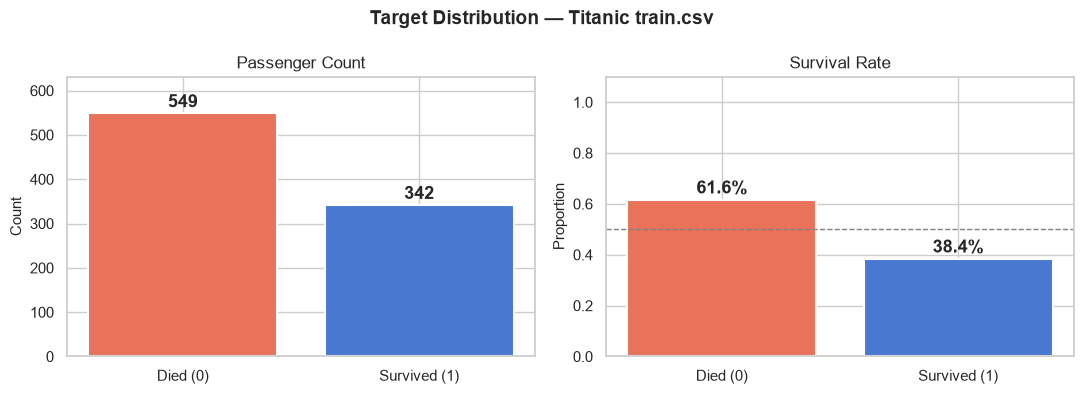

Total   : 891
Survived: 342 (38.4%)
Died    : 549 (61.6%)

Baseline accuracy (predict all-died): 0.616


In [5]:
survived = df["Survived"].sum()
died = len(df) - survived
rate = df["Survived"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(["Died (0)", "Survived (1)"], [died, survived],
                   color=[ORANGE, BLUE], edgecolor="white", linewidth=1.5)
for b, v in zip(bars, [died, survived]):
    axes[0].text(b.get_x() + b.get_width()/2, v + 5, str(v),
                 ha="center", va="bottom", fontweight="bold", fontsize=13)
axes[0].set_title("Passenger Count")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, max(died, survived) * 1.15)

bars2 = axes[1].bar(["Died (0)", "Survived (1)"], [1 - rate, rate],
                    color=[ORANGE, BLUE], edgecolor="white", linewidth=1.5)
for b, v in zip(bars2, [1 - rate, rate]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}",
                 ha="center", va="bottom", fontweight="bold", fontsize=13)
axes[1].set_title("Survival Rate")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.5, ls="--", color="grey", lw=1)

plt.suptitle("Target Distribution — Titanic train.csv", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total   : {len(df)}")
print(f"Survived: {survived} ({rate:.1%})")
print(f"Died    : {died} ({1-rate:.1%})")
print(f"\nBaseline accuracy (predict all-died): {1-rate:.3f}")

---
<a id='3-missing-values'></a>
## 3. Missing Values

Columns with missing values:


,Missing #,Missing %
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


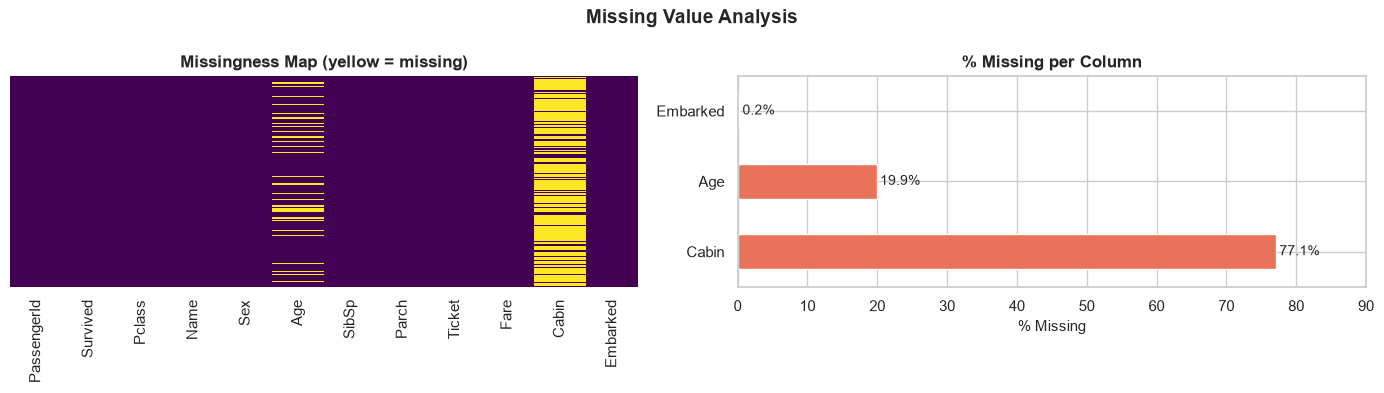


Decision:
  Cabin    77.1% missing -- too sparse to fill reliably, dropped (not used)
  Age      19.9% missing -- KEEP: children survive more, this is real signal.
                            Impute the gaps with median Age per Title group (see section 7).
  Embarked    2  missing -- negligible, fill with mode (S)

Note: 'impute' = fill missing values with a reasonable estimate so the column
      stays usable, instead of discarding a useful feature. We use the median Age
      of each Title group (e.g. Master ~4, Mr ~30) rather than one global median.


In [6]:
missing = df.isna().sum()
miss_pct = (missing / len(df) * 100).round(1)
miss_tbl = (pd.DataFrame({"Missing #": missing, "Missing %": miss_pct})
            .query("`Missing #` > 0").sort_values("Missing #", ascending=False))

print("Columns with missing values:")
display(miss_tbl)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap="viridis", ax=axes[0])
axes[0].set_title("Missingness Map (yellow = missing)", fontweight="bold")

miss_tbl["Missing %"].plot.barh(ax=axes[1], color="#E8735A", edgecolor="white")
axes[1].set_title("% Missing per Column", fontweight="bold")
axes[1].set_xlabel("% Missing")
for i, v in enumerate(miss_tbl["Missing %"]):
    axes[1].text(v + 0.5, i, f"{v}%", va="center", fontsize=10)
axes[1].set_xlim(0, 90)

plt.suptitle("Missing Value Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nDecision:")
print("  Cabin    77.1% missing -- too sparse to fill reliably, dropped (not used)")
print("  Age      19.9% missing -- KEEP: children survive more, this is real signal.")
print("                            Impute the gaps with median Age per Title group (see section 7).")
print("  Embarked    2  missing -- negligible, fill with mode (S)")
print()
print("Note: 'impute' = fill missing values with a reasonable estimate so the column")
print("      stays usable, instead of discarding a useful feature. We use the median Age")
print("      of each Title group (e.g. Master ~4, Mr ~30) rather than one global median.")

---
<a id='4-feature-distributions-univariate'></a>
## 4. Feature Distributions (Univariate)

Shape, range, and outliers for each feature before relating to the target.

> **Why log1p(Fare)?** Fare ranges from 0 to 512 with most passengers paying under 30 GBP.
> This extreme right-skew makes the raw chart almost unreadable (everything squished on the left).
> `log1p(x) = log(1 + x)` compresses the scale so the full shape is visible.
> We show both raw and transformed side-by-side so you can see the difference.

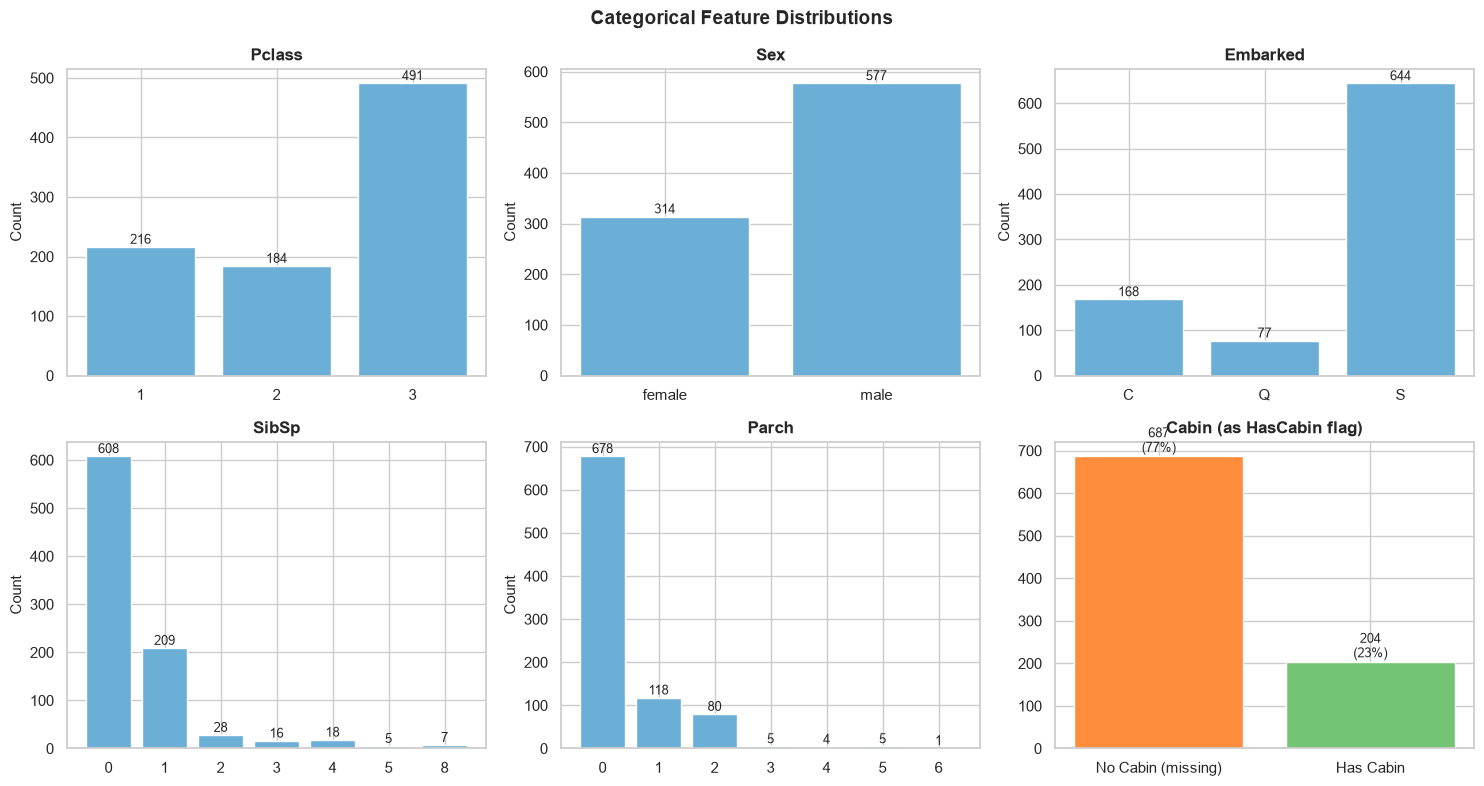

In [7]:
cat_cols = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), cat_cols):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="#6baed6", edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")
    for i, v in enumerate(vc.values):
        ax.text(i, v + 1, str(v), ha="center", va="bottom", fontsize=9)

ax = axes.ravel()[-1]
hc = df["Cabin"].notna()
vc = hc.value_counts().sort_index()
ax.bar(["No Cabin (missing)", "Has Cabin"], vc.values,
       color=["#fd8d3c", "#74c476"], edgecolor="white")
ax.set_title("Cabin (as HasCabin flag)", fontweight="bold")
for i, v in enumerate(vc.values):
    ax.text(i, v + 1, f"{v}\n({v/len(df):.0%})", ha="center", va="bottom", fontsize=9)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

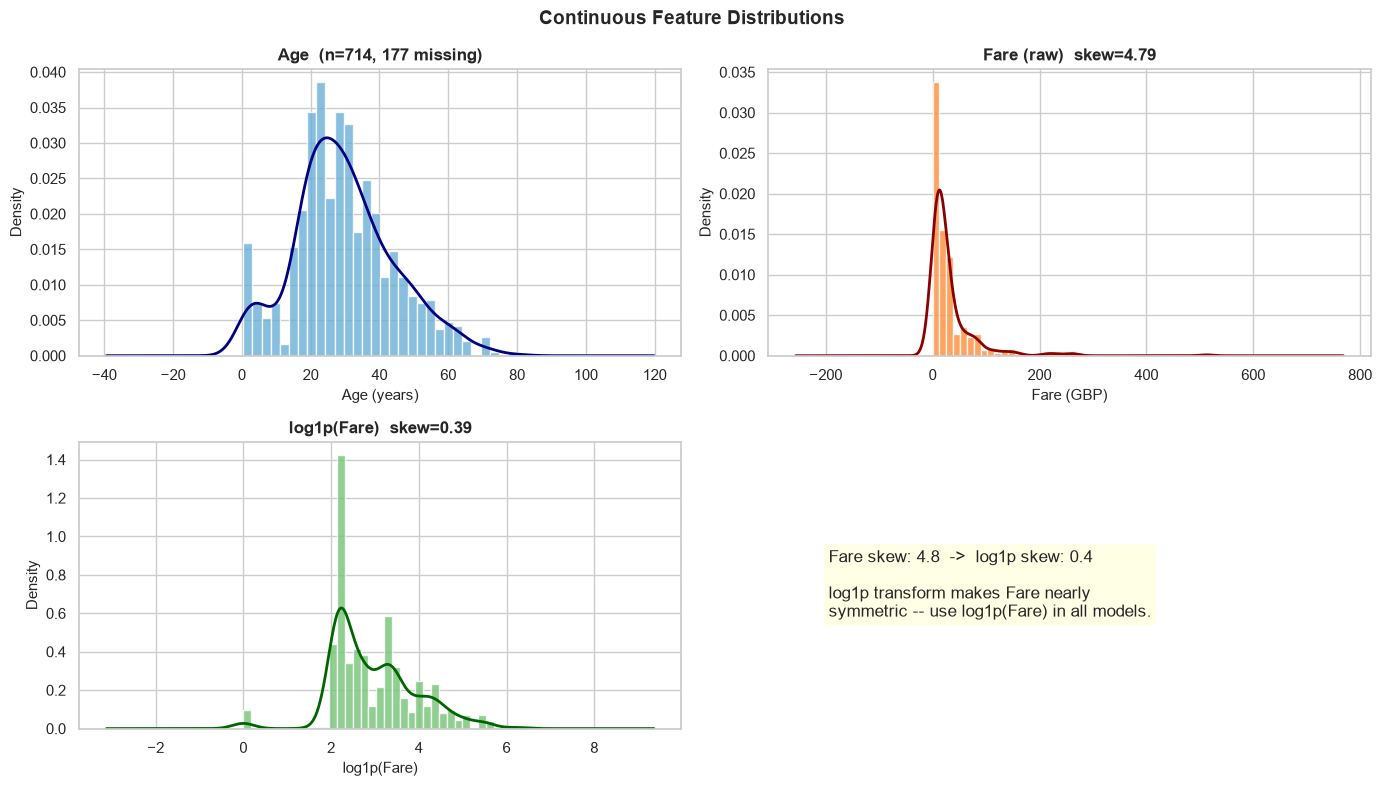

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

age_valid = df["Age"].dropna()
axes[0, 0].hist(age_valid, bins=30, color="#6baed6", edgecolor="white", alpha=0.8, density=True)
age_valid.plot.kde(ax=axes[0, 0], color="navy", lw=2)
axes[0, 0].set_title(f"Age  (n={len(age_valid)}, {df.Age.isna().sum()} missing)", fontweight="bold")
axes[0, 0].set_xlabel("Age (years)")

axes[0, 1].hist(df["Fare"], bins=40, color="#fd8d3c", edgecolor="white", alpha=0.8, density=True)
df["Fare"].plot.kde(ax=axes[0, 1], color="darkred", lw=2)
axes[0, 1].set_title(f"Fare (raw)  skew={df.Fare.skew():.2f}", fontweight="bold")
axes[0, 1].set_xlabel("Fare (GBP)")

log_fare = np.log1p(df["Fare"])
axes[1, 0].hist(log_fare, bins=35, color="#74c476", edgecolor="white", alpha=0.8, density=True)
log_fare.plot.kde(ax=axes[1, 0], color="darkgreen", lw=2)
axes[1, 0].set_title(f"log1p(Fare)  skew={log_fare.skew():.2f}", fontweight="bold")
axes[1, 0].set_xlabel("log1p(Fare)")

axes[1, 1].axis("off")
axes[1, 1].text(0.1, 0.5,
    "Fare skew: 4.8  ->  log1p skew: 0.4\n\n"
    "log1p transform makes Fare nearly\n"
    "symmetric -- use log1p(Fare) in all models.",
    transform=axes[1, 1].transAxes, fontsize=12, va="center",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Continuous Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
<a id='5-survival-breakdown-per-feature-bivariate'></a>
## 5. Survival Breakdown per Feature (Bivariate)

Dashed grey line = overall survival rate (38.4%).

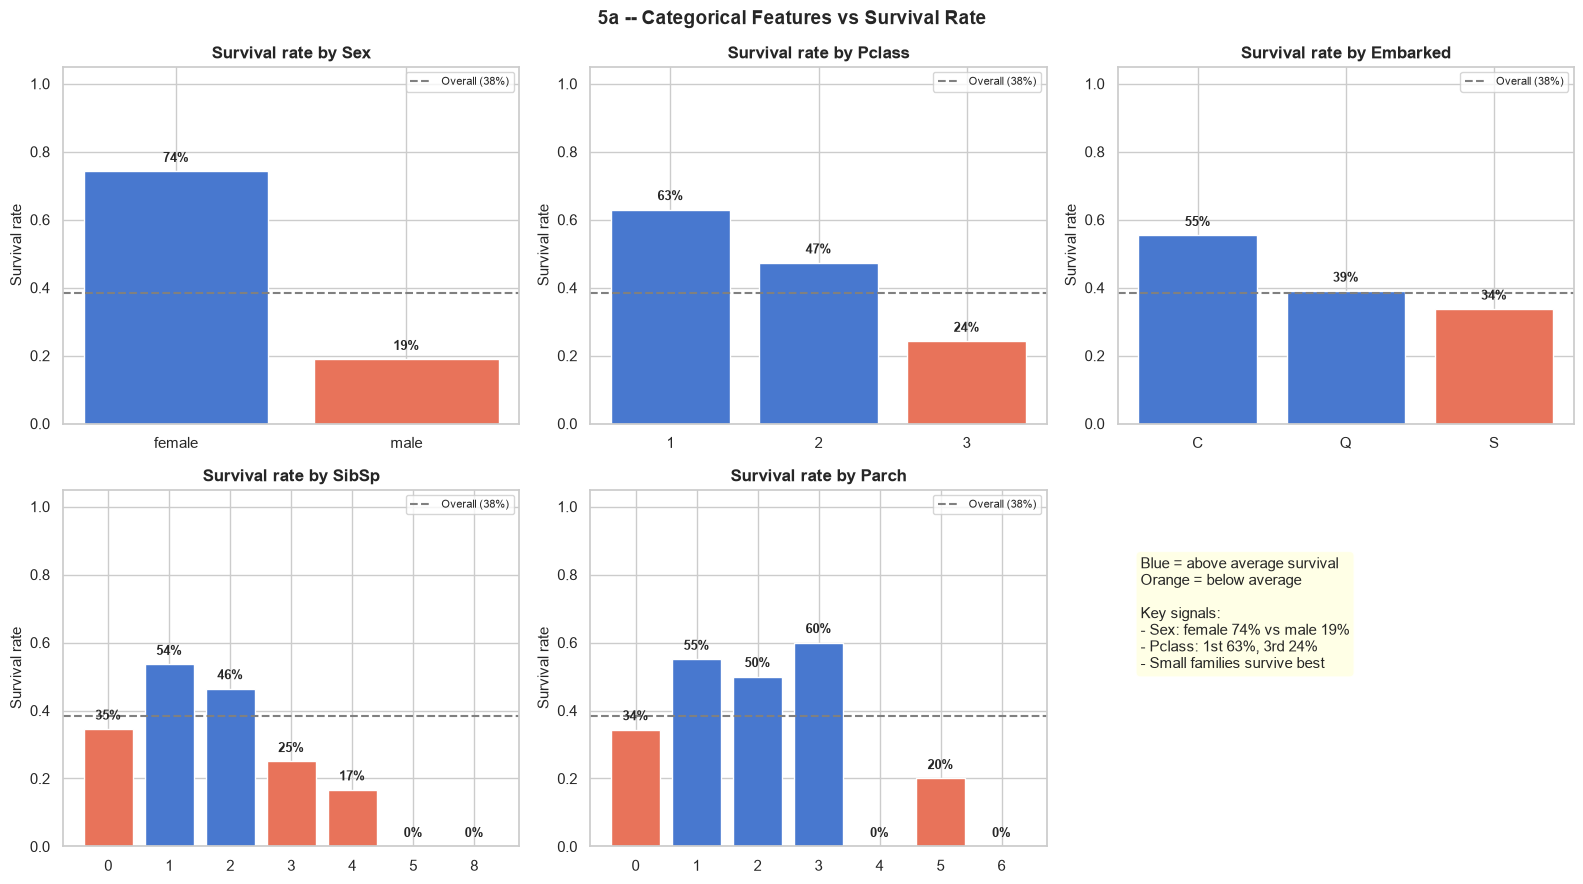

In [9]:
mean_surv = df["Survived"].mean()
cat_cols_surv = ["Sex", "Pclass", "Embarked", "SibSp", "Parch"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.ravel(), cat_cols_surv):
    grp = df.groupby(col)["Survived"].mean().sort_index()
    colors = [BLUE if v > mean_surv else ORANGE for v in grp.values]
    bars = ax.bar(grp.index.astype(str), grp.values, color=colors, edgecolor="white")
    ax.axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
    ax.set_title(f"Survival rate by {col}", fontweight="bold")
    ax.set_ylabel("Survival rate")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    for b, v in zip(bars, grp.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.0%}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

axes.ravel()[-1].axis("off")
axes.ravel()[-1].text(0.05, 0.5,
    "Blue = above average survival\nOrange = below average\n\n"
    "Key signals:\n"
    "- Sex: female 74% vs male 19%\n"
    "- Pclass: 1st 63%, 3rd 24%\n"
    "- Small families survive best",
    transform=axes.ravel()[-1].transAxes, fontsize=11,
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("5a -- Categorical Features vs Survival Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

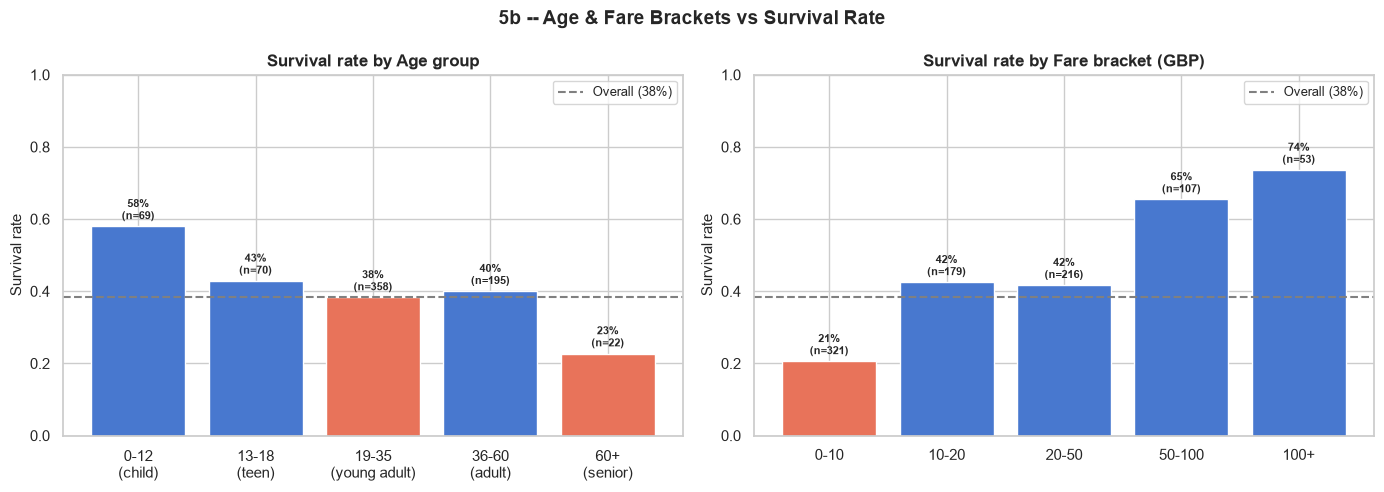

Age group survival rates:
  0-12 (child)          : 58.0%  (n=69)
  13-18 (teen)          : 42.9%  (n=70)
  19-35 (young adult)   : 38.3%  (n=358)
  36-60 (adult)         : 40.0%  (n=195)
  60+ (senior)          : 22.7%  (n=22)

Fare bracket survival rates:
  GBP 0-10      : 20.6%  (n=321)
  GBP 10-20     : 42.5%  (n=179)
  GBP 20-50     : 41.7%  (n=216)
  GBP 50-100    : 65.4%  (n=107)
  GBP 100+      : 73.6%  (n=53)


In [10]:
mean_surv = df["Survived"].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age bins
age_bins   = [0, 12, 18, 35, 60, 100]
age_labels = ["0-12\n(child)", "13-18\n(teen)", "19-35\n(young adult)", "36-60\n(adult)", "60+\n(senior)"]
tmp_age = df.dropna(subset=["Age"]).copy()
tmp_age["AgeBin"] = pd.cut(tmp_age["Age"], bins=age_bins, labels=age_labels)
age_surv = tmp_age.groupby("AgeBin", observed=True)["Survived"].mean()
age_cnt  = tmp_age.groupby("AgeBin", observed=True)["Survived"].count()
colors = [BLUE if v > mean_surv else ORANGE for v in age_surv.values]
bars = axes[0].bar(age_surv.index, age_surv.values, color=colors, edgecolor="white")
axes[0].axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
axes[0].set_title("Survival rate by Age group", fontweight="bold")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=9)
for b, (v, n) in zip(bars, zip(age_surv.values, age_cnt.values)):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.0%}\n(n={n})",
                 ha="center", fontsize=8, fontweight="bold")

# Fare bins
fare_bins   = [0, 10, 20, 50, 100, 600]
fare_labels = ["0-10", "10-20", "20-50", "50-100", "100+"]
tmp_fare = df.copy()
tmp_fare["FareBin"] = pd.cut(tmp_fare["Fare"], bins=fare_bins, labels=fare_labels)
fare_surv = tmp_fare.groupby("FareBin", observed=True)["Survived"].mean()
fare_cnt  = tmp_fare.groupby("FareBin", observed=True)["Survived"].count()
colors = [BLUE if v > mean_surv else ORANGE for v in fare_surv.values]
bars = axes[1].bar(fare_surv.index, fare_surv.values, color=colors, edgecolor="white")
axes[1].axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
axes[1].set_title("Survival rate by Fare bracket (GBP)", fontweight="bold")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=9)
for b, (v, n) in zip(bars, zip(fare_surv.values, fare_cnt.values)):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.0%}\n(n={n})",
                 ha="center", fontsize=8, fontweight="bold")

plt.suptitle("5b -- Age & Fare Brackets vs Survival Rate", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Age group survival rates:")
for lbl, v, n in zip(age_labels, age_surv.values, age_cnt.values):
    print(f"  {lbl.replace(chr(10),' '):22s}: {v:.1%}  (n={n})")
print("\nFare bracket survival rates:")
for lbl, v, n in zip(fare_labels, fare_surv.values, fare_cnt.values):
    print(f"  GBP {lbl:10s}: {v:.1%}  (n={n})")

---
<a id='6-correlations--interactions'></a>
## 6. Correlations & Interactions

Two charts, each answering a different question:

**Left — Correlation heatmap:** how strongly each numeric feature moves with every other.
A value near +1 means they rise together; near -1 means one rises as the other falls; near 0 = no linear relationship.
The `Survived` row/column shows which raw numbers are predictive.
We also look for features correlated with *each other* (multicollinearity) since redundant inputs waste model capacity.

**Right — Sex x Pclass survival pivot:** the single most important interaction in this dataset.
Does the Sex effect differ by class? A flat grid would mean no interaction.
The dramatic range we see means these two features combine non-additively — any model must capture this.

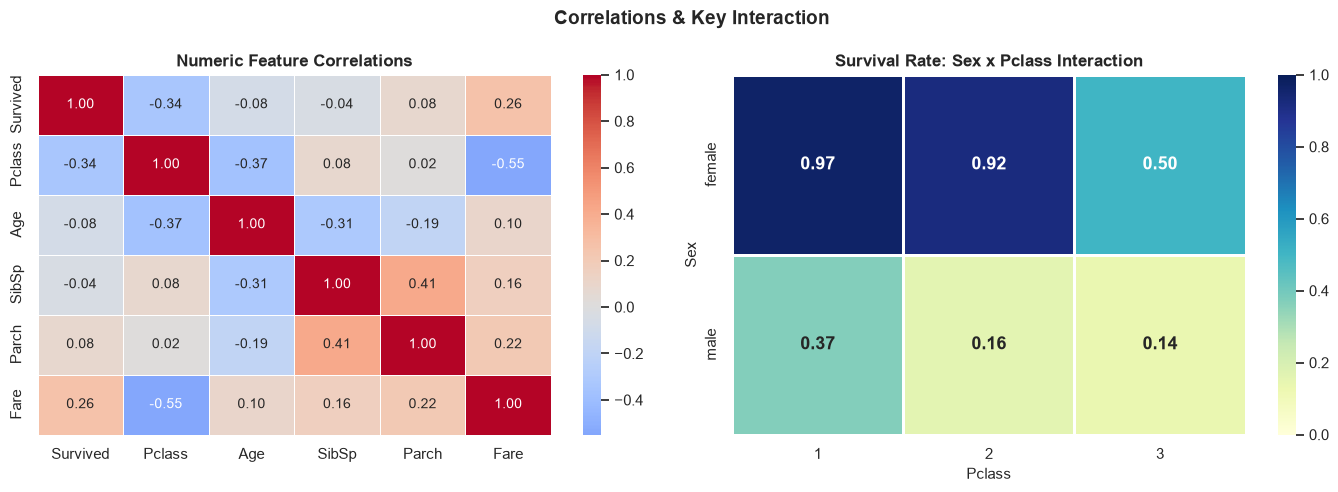

Strongest positive correlate (Survived): Fare   0.257
Strongest negative correlate (Survived): Pclass -0.338

Sex x Pclass survival rates:


Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [11]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[0], linewidths=0.5, annot_kws={"size": 10})
axes[0].set_title("Numeric Feature Correlations", fontweight="bold")

pivot = df.pivot_table(index="Sex", columns="Pclass",
                       values="Survived", aggfunc="mean").round(3)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu",
            vmin=0, vmax=1, ax=axes[1],
            annot_kws={"size": 13, "weight": "bold"}, linewidths=1)
axes[1].set_title("Survival Rate: Sex x Pclass Interaction", fontweight="bold")

plt.suptitle("Correlations & Key Interaction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Strongest positive correlate (Survived): Fare  ", round(corr.loc["Fare", "Survived"], 3))
print("Strongest negative correlate (Survived): Pclass", round(corr.loc["Pclass", "Survived"], 3))
print("\nSex x Pclass survival rates:")
display(pivot)

**Interpretation:**

*Correlation heatmap:*
- `Pclass` has the strongest negative correlation with `Survived` (-0.34): higher class number (poorer) = less likely to survive.
- `Fare` has the strongest positive correlation (+0.26): paid more = more likely to survive (largely a Pclass proxy).
- `Fare` and `Pclass` are correlated with each other (-0.55): they carry overlapping information — we may only need one.
- `Age` shows a weak negative correlation (-0.08): slight tendency for older passengers to survive less, but not strong alone.

*Sex x Pclass pivot:*
- 1st/2nd-class women survived at 92-97% — evacuated first, no exceptions.
- 3rd-class men survived at just 14% — worst outcome by far.
- The female survival advantage *shrinks in 3rd class* — "women and children first" was less strictly applied lower in the ship.
- This is why Sex and Pclass together are far more powerful than either alone.

<a id='6-1-pclass--fare'></a>
### 6.1 Pclass & Fare vs Survival

**Question:** Does paying more genuinely increase your chances, or is Fare just a proxy for Pclass?

The chart below shows the log1p(Fare) distribution per class split by outcome.
If Fare adds information *beyond* Pclass, we should see survived passengers paid more even *within the same class*.
If Fare is purely redundant, the survived/died boxes should overlap within each class.

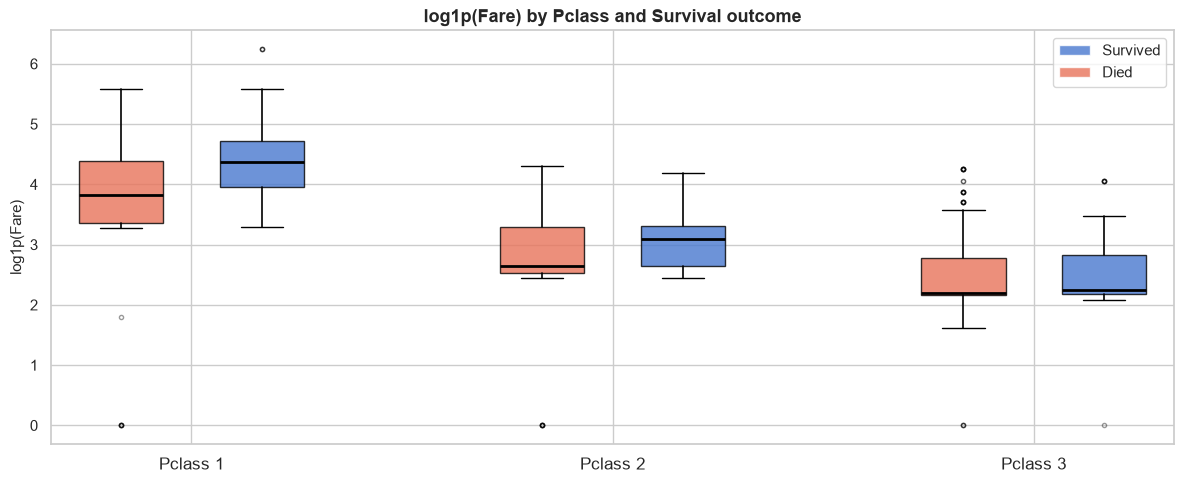

Median Fare (raw GBP) by Pclass and Survival:
Survived  Died  Survived
Pclass                  
1         44.8      78.0
2         13.0      21.0
3          8.0       8.5


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

pclasses = [1, 2, 3]
tick_positions = []

for i, pclass in enumerate(pclasses):
    for j, (surv, label, color) in enumerate([(0, "Died", ORANGE), (1, "Survived", BLUE)]):
        data = np.log1p(df.loc[(df.Pclass == pclass) & (df.Survived == surv), "Fare"].dropna())
        pos = i * 3 + j
        bp = ax.boxplot(data, positions=[pos], widths=0.6, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        flierprops=dict(marker="o", markersize=3, alpha=0.4))
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.8)
    tick_positions.append(i * 3 + 0.5)

ax.set_xticks(tick_positions)
ax.set_xticklabels([f"Pclass {p}" for p in pclasses], fontsize=12)
ax.set_ylabel("log1p(Fare)")
ax.set_title("log1p(Fare) by Pclass and Survival outcome", fontweight="bold", fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=BLUE, alpha=0.8, label="Survived"),
                   Patch(facecolor=ORANGE, alpha=0.8, label="Died")]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.show()

# Exact median RAW fare (GBP) per class & outcome -- the precise companion to the boxplot above
print("Median Fare (raw GBP) by Pclass and Survival:")
print(df.groupby(["Pclass", "Survived"])["Fare"].median().round(1).unstack()
      .rename(columns={0: "Died", 1: "Survived"}))

**Interpretation:**

- In 1st and 2nd class, survivors paid noticeably more than those who died (1st class: ~45 vs ~78 GBP) -- Fare carries a small extra signal beyond Pclass.
- In 3rd class the gap almost vanishes (~8.1 vs ~8.5) -- once you were in 3rd class, paying a little more barely changed your odds.
- The class-to-class jump dwarfs the within-class survived/died gap, confirming Fare is *mostly* a Pclass proxy.
- 3rd-class passengers who paid more still survived far less often than 1st-class passengers who paid less.
- **Conclusion:** Pclass dominates; log1p(Fare) adds a small complementary signal. We keep both and expect Pclass to lead.

<a id='6-2-sibsp--parch'></a>
### 6.2 SibSp & Parch Interaction vs Survival

**Question:** Do SibSp and Parch interact — does having siblings affect survival differently depending on whether you also have parents/children aboard?

A pivot heatmap (SibSp × Parch → survival rate) answers this directly.
Empty/grey cells are combinations that don't exist in the data (e.g. 8 siblings + 5 parents).

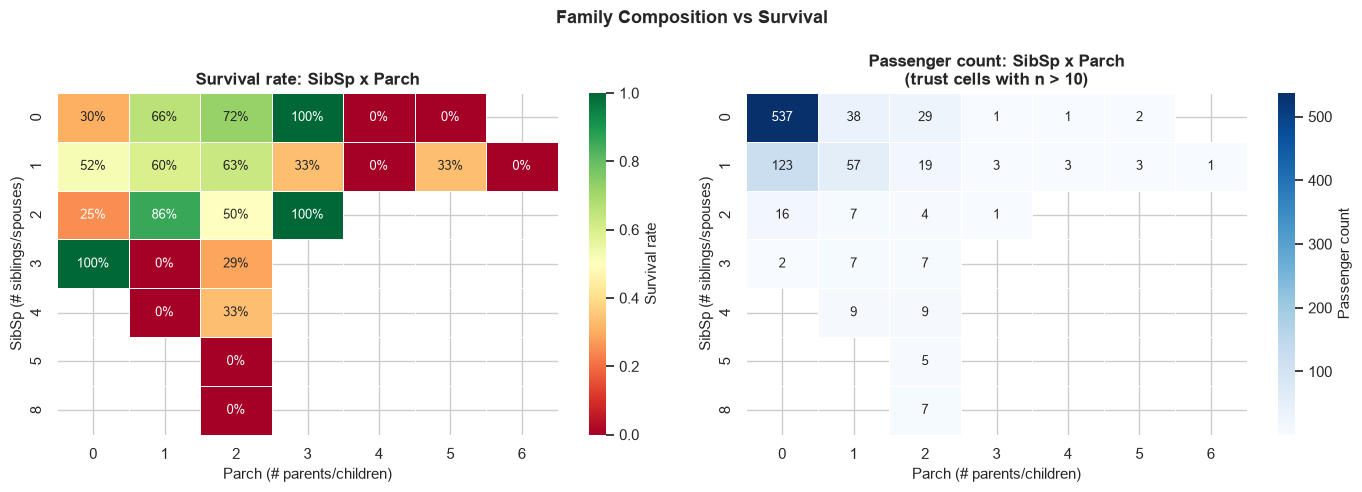

In [13]:
pivot_family = df.groupby(["SibSp", "Parch"])["Survived"].agg(["mean", "count"])
pivot_mean = pivot_family["mean"].unstack(fill_value=np.nan)
pivot_count = pivot_family["count"].unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate heatmap
mask = pivot_mean.isna()
sns.heatmap(pivot_mean, annot=True, fmt=".0%", cmap="RdYlGn",
            vmin=0, vmax=1, ax=axes[0], mask=mask,
            linewidths=0.5, annot_kws={"size": 9},
            cbar_kws={"label": "Survival rate"})
axes[0].set_title("Survival rate: SibSp x Parch", fontweight="bold")
axes[0].set_xlabel("Parch (# parents/children)")
axes[0].set_ylabel("SibSp (# siblings/spouses)")

# Count heatmap so we know which cells are statistically meaningful
mask2 = pivot_count == 0
sns.heatmap(pivot_count, annot=True, fmt="d", cmap="Blues",
            ax=axes[1], mask=mask2,
            linewidths=0.5, annot_kws={"size": 9},
            cbar_kws={"label": "Passenger count"})
axes[1].set_title("Passenger count: SibSp x Parch\n(trust cells with n > 10)", fontweight="bold")
axes[1].set_xlabel("Parch (# parents/children)")
axes[1].set_ylabel("SibSp (# siblings/spouses)")

plt.suptitle("Family Composition vs Survival", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:**

- **Travelling alone (SibSp=0, Parch=0):** ~30% survival -- the worst single group by count.
- **Small nuclear family (SibSp=0-1, Parch=1-2):** highest survival rates (50-70%+) -- enough people to help each other without being hard to evacuate.
- **Large families (SibSp >= 3 or Parch >= 3):** survival collapses -- hard to keep track of everyone during evacuation.
- **SibSp and Parch interact:** having 1 sibling *with* 1-2 parents/children gives better odds than either alone.
- **Takeaway:** we keep **all three** -- raw `SibSp`, raw `Parch`, and the combined `FamilySize`. FamilySize captures the overall trend, while SibSp and Parch each retain nuance (siblings/spouses behave differently from parents/children) that a single combined number loses.

---
<a id='7-engineered-feature-previews'></a>
## 7. Engineered Feature Previews

The EDA above flagged several features worth constructing from the raw columns. Here we build each, check it actually separates survivors, and end every subsection with a **keep / drop** verdict.

<a id='7-1-title'></a>
### 7.1 Title

Extracted from `Name`. We inspect every raw title, choose a grouping, and validate its survival signal. The per-title median age also drives the Age imputation from section 3.

In [14]:
tmp = df.copy()

# Extract raw titles — no replacement, just look at what exists
title_raw = tmp["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
tmp["Title_raw"] = title_raw

print("=== All raw titles in the dataset ===")
title_counts = tmp["Title_raw"].value_counts()
display(title_counts.to_frame("Count"))
print(f"\nTotal unique titles: {tmp['Title_raw'].nunique()}")
print("\nSurvival rate by raw title:")
display(tmp.groupby("Title_raw")["Survived"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "Survival Rate", "count": "Count"})
        .sort_values("Count", ascending=False).round(3))

=== All raw titles in the dataset ===


,Count
Title_raw,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Major,2
Mlle,2
Col,2



Total unique titles: 17

Survival rate by raw title:


,Survival Rate,Count
Title_raw,,
Mr,0.157,517
Miss,0.698,182
Mrs,0.792,125
Master,0.575,40
Dr,0.429,7
Rev,0.000,6
Mlle,1.000,2
Major,0.500,2
Col,0.500,2


**What each title means:**

| Title | Meaning |
|---|---|
| `Mr` | Adult man (married or unmarried) |
| `Mrs` | Married woman |
| `Miss` | Unmarried woman or girl |
| `Master` | A **boy** -- historical courtesy title for males under ~13. This is why it is such a strong age signal (median age ~4) |
| `Dr` | Doctor (medical or academic) |
| `Rev` | Reverend / clergy |
| `Other` | Rare aristocratic & military titles (Major, Col, Capt, Don, Sir, Lady, the Countess, Jonkheer) plus alternate forms (Mlle, Mme, Ms), combined because each occurs only 1-2 times |

**Grouping scheme:** keep `Mr`, `Miss`, `Mrs`, `Master`, `Dr`, `Rev`; fold everything else into `Other` -> **7 classes**.


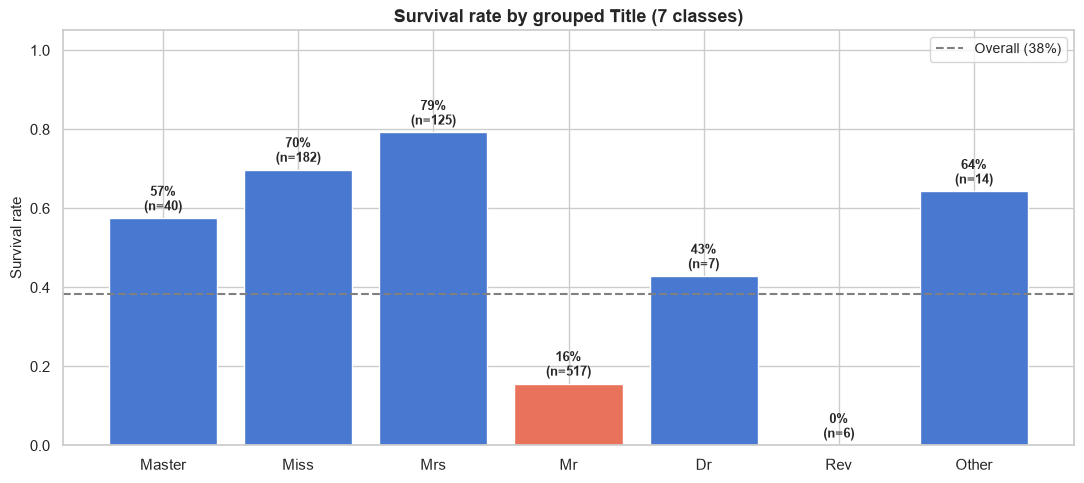

Grouped Title survival rates:


,Survival Rate,Count
Title,,
Master,0.575,40
Miss,0.698,182
Mrs,0.792,125
Mr,0.157,517
Dr,0.429,7
Rev,0.000,6
Other,0.643,14


In [15]:
# Apply the 7-class grouping
KEEP_TITLES = ["Mr", "Miss", "Mrs", "Master", "Dr", "Rev"]
tmp["Title"] = tmp["Title_raw"].where(tmp["Title_raw"].isin(KEEP_TITLES), "Other")

mean_surv = df["Survived"].mean()
order = ["Master", "Miss", "Mrs", "Mr", "Dr", "Rev", "Other"]
t_surv = tmp.groupby("Title")["Survived"].mean().reindex(order)
t_cnt  = tmp.groupby("Title")["Survived"].count().reindex(order)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [BLUE if v > mean_surv else ORANGE for v in t_surv.values]
bars = ax.bar(order, t_surv.values, color=colors, edgecolor='white')
ax.axhline(mean_surv, ls='--', color='grey', lw=1.5, label=f'Overall ({mean_surv:.0%})')
ax.set_title('Survival rate by grouped Title (7 classes)', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival rate')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
for b, (v, n) in zip(bars, zip(t_surv.values, t_cnt.values)):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.0%}\n(n={n})',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('Grouped Title survival rates:')
display(tmp.groupby('Title')['Survived'].agg(['mean', 'count'])
        .reindex(order).round(3)
        .rename(columns={'mean': 'Survival Rate', 'count': 'Count'}))

In [16]:
# Title also enables the Age imputation decided in section 3.
# Median Age differs sharply by title, so per-Title median beats a single global median.
print(f'Global median Age = {df["Age"].median():.0f} yrs (ignores that Master are boys ~4, Mr ~30)\n')
print('Median Age by grouped Title (the values we impute missing ages with):')
display(tmp.groupby('Title')['Age']
        .agg(['median', 'count'])
        .reindex(order)
        .round(1)
        .rename(columns={'median': 'Median Age', 'count': 'Count'}))

Global median Age = 28 yrs (ignores that Master are boys ~4, Mr ~30)

Median Age by grouped Title (the values we impute missing ages with):


,Median Age,Count
Title,,
Master,3.5,36
Miss,21.0,146
Mrs,35.0,108
Mr,30.0,398
Dr,46.5,6
Rev,46.5,6
Other,42.5,14


<a id='7-2-family-features'></a>
### 7.2 Family Features (FamilySize & IsAlone)

Combining `SibSp` + `Parch` into total family size, plus a solo-traveller flag.

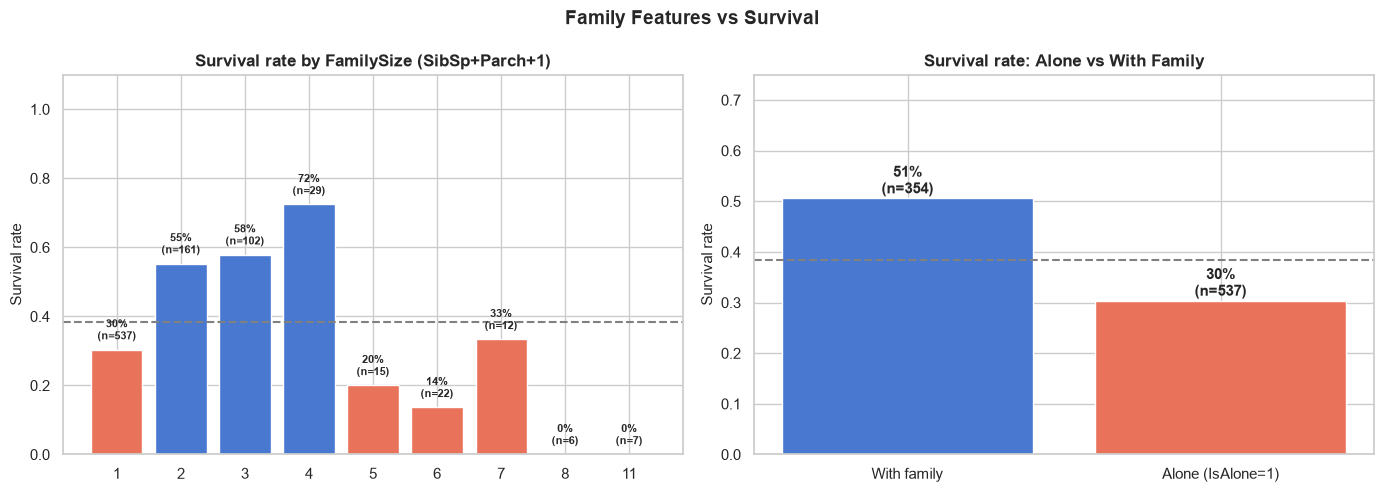

In [17]:
tmp["FamilySize"] = tmp["SibSp"] + tmp["Parch"] + 1
tmp["IsAlone"]   = (tmp["FamilySize"] == 1).astype(int)
mean_surv = df["Survived"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FamilySize
fs_surv = tmp.groupby("FamilySize")["Survived"].mean()
fs_cnt  = tmp.groupby("FamilySize")["Survived"].count()
axes[0].bar(fs_surv.index.astype(str), fs_surv.values,
            color=[BLUE if v > mean_surv else ORANGE for v in fs_surv.values],
            edgecolor="white")
axes[0].axhline(mean_surv, ls="--", color="grey", lw=1.5)
axes[0].set_title("Survival rate by FamilySize (SibSp+Parch+1)", fontweight="bold")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1.1)
for i, (v, n) in enumerate(zip(fs_surv.values, fs_cnt.values)):
    axes[0].text(i, v + 0.03, f"{v:.0%}\n(n={n})", ha="center", fontsize=8, fontweight="bold")

# IsAlone
ia_surv = tmp.groupby("IsAlone")["Survived"].mean()
ia_cnt  = tmp.groupby("IsAlone")["Survived"].count()
axes[1].bar(["With family", "Alone (IsAlone=1)"], ia_surv.values,
            color=[BLUE, ORANGE], edgecolor="white")
axes[1].axhline(mean_surv, ls="--", color="grey", lw=1.5)
axes[1].set_title("Survival rate: Alone vs With Family", fontweight="bold")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 0.75)
for i, (v, n) in enumerate(zip(ia_surv.values, ia_cnt.values)):
    axes[1].text(i, v + 0.01, f"{v:.0%}\n(n={n})", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Family Features vs Survival", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<a id='7-3-ticketgroupsize'></a>
### 7.3 TicketGroupSize

`Ticket` is just an ID, but passengers sharing a ticket travelled together — not necessarily as declared family. Three steps:

1. **Data check** — do passengers on the same ticket share the same fare? (is the ticket grouping clean?)
2. **Predictive value** — does ticket group size relate to survival?
3. **Redundancy check** — does it add anything beyond FamilySize?

In [18]:
# Step 1: do passengers sharing a ticket always have the same fare?
ticket_stats = df.groupby("Ticket").agg(
    group_size=("PassengerId", "count"),
    fare_unique=("Fare", "nunique"),
    fare_min=("Fare", "min"),
    fare_max=("Fare", "max"),
)

shared   = ticket_stats[ticket_stats["group_size"] > 1]
same     = shared[shared["fare_unique"] == 1]
diff_fare = shared[shared["fare_unique"] > 1]

print("=== Fare consistency within shared tickets ===")
print(f"Shared tickets (2+ passengers) : {len(shared)}")
print(f"  All same fare                : {len(same)} ({len(same)/len(shared):.1%})")
print(f"  Different fares within group : {len(diff_fare)} ({len(diff_fare)/len(shared):.1%})")
print()
print("The one exception (different fares):")
display(df[df["Ticket"].isin(diff_fare.index)]
        [["Ticket","Name","Pclass","Fare"]].sort_values("Ticket"))
print()
print("Sample of tickets with identical fares:")
display(df[df["Ticket"].isin(same.index[:2])]
        [["Ticket","Name","Pclass","Fare"]].sort_values("Ticket"))

=== Fare consistency within shared tickets ===
Shared tickets (2+ passengers) : 134
  All same fare                : 133 (99.3%)
  Different fares within group : 1 (0.7%)

The one exception (different fares):


,Ticket,Name,Pclass,Fare
138,7534,"Osen, Mr. Olaf Elon",3,9.2167
876,7534,"Gustafsson, Mr. Alfred Ossian",3,9.8458



Sample of tickets with identical fares:


,Ticket,Name,Pclass,Fare
257,110152,"Cherry, Miss. Gladys",1,86.50
504,110152,"Maioni, Miss. Roberta",1,86.50
759,110152,"Rothes, the Countess. of (Lucy Noel Martha Dye...",1,86.50
262,110413,"Taussig, Mr. Emil",1,79.65
558,110413,"Taussig, Mrs. Emil (Tillie Mandelbaum)",1,79.65
585,110413,"Taussig, Miss. Ruth",1,79.65


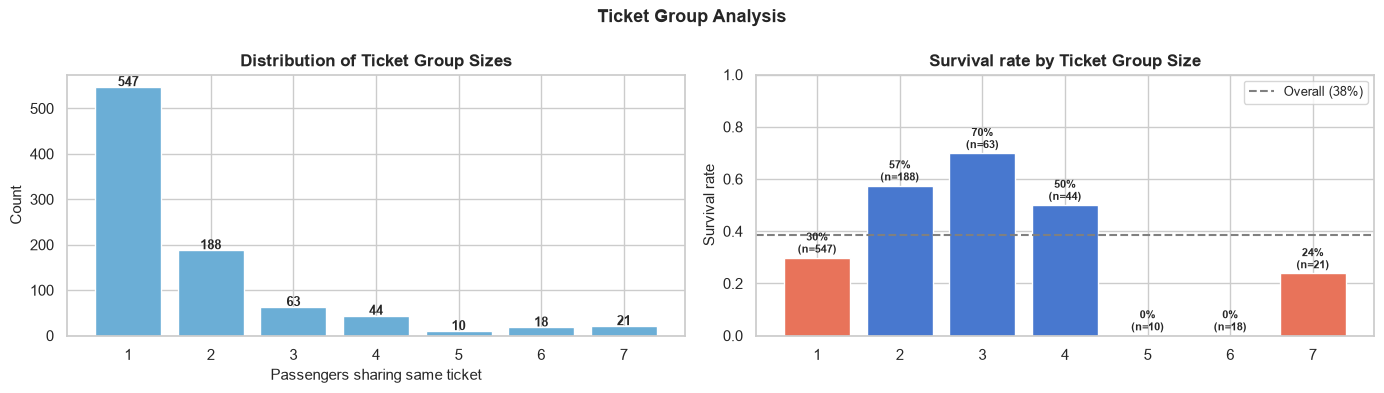

In [19]:
# Step 2: distribution of ticket group sizes + survival by group size
ticket_group_size = df["Ticket"].map(ticket_stats["group_size"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of group sizes
vc = ticket_group_size.value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color="#6baed6", edgecolor="white")
axes[0].set_title("Distribution of Ticket Group Sizes", fontweight="bold")
axes[0].set_xlabel("Passengers sharing same ticket")
axes[0].set_ylabel("Count")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2, str(v), ha="center", fontsize=9, fontweight="bold")

# Survival rate by ticket group size
mean_surv = df["Survived"].mean()
df_tmp = df.copy()
df_tmp["TicketGroupSize"] = ticket_group_size
tg_surv = df_tmp.groupby("TicketGroupSize")["Survived"].mean()
tg_cnt  = df_tmp.groupby("TicketGroupSize")["Survived"].count()
colors = [BLUE if v > mean_surv else ORANGE for v in tg_surv.values]
bars = axes[1].bar(tg_surv.index.astype(str), tg_surv.values, color=colors, edgecolor="white")
axes[1].axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
axes[1].set_title("Survival rate by Ticket Group Size", fontweight="bold")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 1.0)
axes[1].legend(fontsize=9)
for b, (v, n) in zip(bars, zip(tg_surv.values, tg_cnt.values)):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.0%}\n(n={n})",
                 ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Ticket Group Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Agree exactly  : 603 (67.7%)
Disagree       : 288 (32.3%)


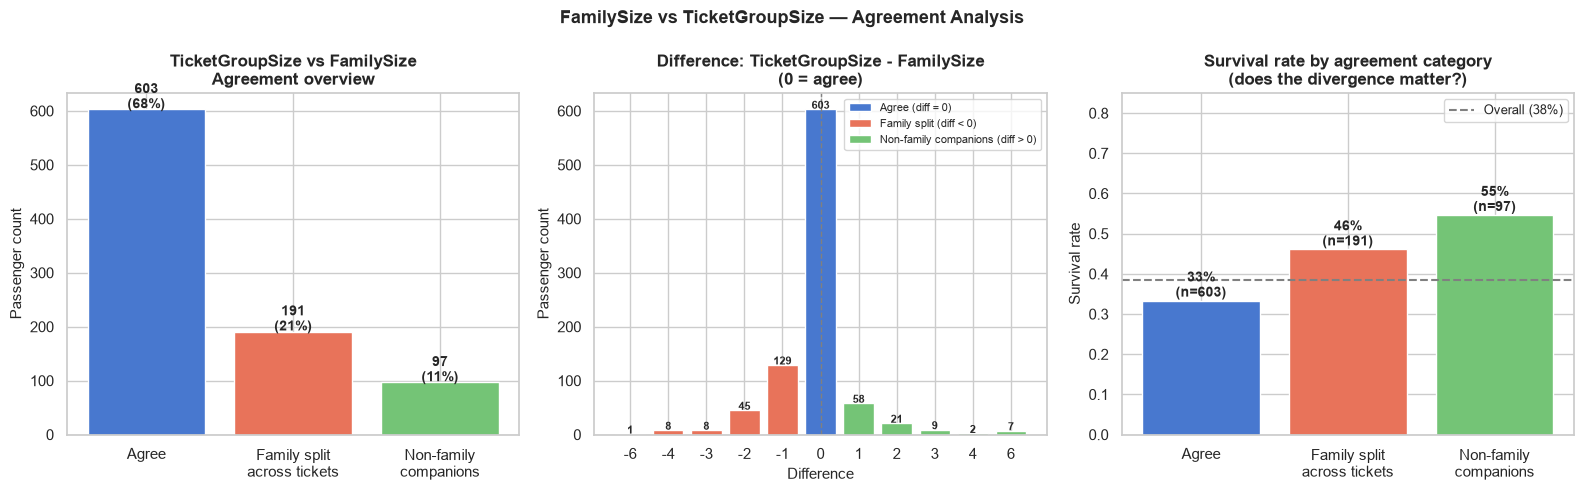

In [20]:
# Step 3: does TicketGroupSize agree with FamilySize (SibSp+Parch+1)?
df_tmp = df.copy()
df_tmp["FamilySize"]      = df_tmp["SibSp"] + df_tmp["Parch"] + 1
df_tmp["TicketGroupSize"] = df_tmp["Ticket"].map(df.groupby("Ticket")["PassengerId"].count())
df_tmp["diff"]            = df_tmp["TicketGroupSize"] - df_tmp["FamilySize"]

agree    = (df_tmp["diff"] == 0).sum()
disagree = (df_tmp["diff"] != 0).sum()
total    = len(df_tmp)

print(f"Agree exactly  : {agree} ({agree/total:.1%})")
print(f"Disagree       : {disagree} ({disagree/total:.1%})")

# Categorise disagreements
def categorise(d):
    if d == 0:   return "Agree"
    elif d < 0:  return "Family split\nacross tickets"
    else:        return "Non-family\ncompanions"

df_tmp["DiffCategory"] = df_tmp["diff"].apply(categorise)

diff_counts = df_tmp["diff"].value_counts().sort_index()
cat_counts  = df_tmp["DiffCategory"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: agree vs disagree (simple overview)
cat_order  = ["Agree", "Family split\nacross tickets", "Non-family\ncompanions"]
cat_colors = [BLUE, ORANGE, "#74c476"]
cat_vals   = [cat_counts.get(c, 0) for c in cat_order]
bars = axes[0].bar(cat_order, cat_vals, color=cat_colors, edgecolor="white")
axes[0].set_title("TicketGroupSize vs FamilySize\nAgreement overview", fontweight="bold")
axes[0].set_ylabel("Passenger count")
for b, v in zip(bars, cat_vals):
    axes[0].text(b.get_x() + b.get_width()/2, v + 2,
                 f"{v}\n({v/total:.0%})", ha="center", fontsize=10, fontweight="bold")

# Chart 2: full diff distribution (signed bar chart)
colors_diff = [BLUE if i == 0 else "#74c476" if i > 0 else ORANGE
               for i in diff_counts.index]
bars2 = axes[1].bar(diff_counts.index.astype(str), diff_counts.values,
                    color=colors_diff, edgecolor="white")
axes[1].set_title("Difference: TicketGroupSize - FamilySize\n(0 = agree)", fontweight="bold")
axes[1].set_xlabel("Difference")
axes[1].set_ylabel("Passenger count")
axes[1].axvline(x=diff_counts.index.tolist().index(0), color="grey", ls="--", lw=1)
for b, v in zip(bars2, diff_counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 1,
                 str(v), ha="center", fontsize=8, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=BLUE,      label="Agree (diff = 0)"),
                   Patch(facecolor=ORANGE,    label="Family split (diff < 0)"),
                   Patch(facecolor="#74c476", label="Non-family companions (diff > 0)")]
axes[1].legend(handles=legend_elements, fontsize=8)

# Chart 3: survival rate per category
surv_cat = df_tmp.groupby("DiffCategory")["Survived"].mean()
surv_cnt = df_tmp.groupby("DiffCategory")["Survived"].count()
mean_surv = df["Survived"].mean()
cat_surv_order = ["Agree", "Family split\nacross tickets", "Non-family\ncompanions"]
surv_vals = [surv_cat.get(c, 0) for c in cat_surv_order]
cnt_vals  = [surv_cnt.get(c, 0) for c in cat_surv_order]
bars3 = axes[2].bar(cat_surv_order, surv_vals, color=cat_colors, edgecolor="white")
axes[2].axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
axes[2].set_title("Survival rate by agreement category\n(does the divergence matter?)", fontweight="bold")
axes[2].set_ylabel("Survival rate")
axes[2].set_ylim(0, 0.85)
axes[2].legend(fontsize=9)
for b, (v, n) in zip(bars3, zip(surv_vals, cnt_vals)):
    axes[2].text(b.get_x() + b.get_width()/2, v + 0.01,
                 f"{v:.0%}\n(n={n})", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("FamilySize vs TicketGroupSize — Agreement Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation:**

*Step 1 — fare consistency:* 133 of 134 shared tickets (99.3%) have identical fares; the single exception differs by ~£0.6. Fare is recorded consistently within a ticket, so `TicketGroupSize` is well-defined.

*Step 2 — group size vs survival:* solo ticket-holders survive least, small groups (2-4) best, very large groups collapse — the same shape as FamilySize.

*Step 3 — divergence from FamilySize:* the two agree only ~68% of the time. Where a passenger has **non-family companions** on their ticket they survive ~55%, vs ~33% when the ticket group is exactly the family — signal FamilySize alone misses.

**Decision:** KEEP `TicketGroupSize` — well-defined, and its divergence from FamilySize carries distinct survival signal.

<a id='7-4-farerank'></a>
### 7.4 FareRank — Relative Fare within Pclass

**Motivation (from §6.1):** Within each Pclass, passengers paid different amounts. A 3rd-class passenger who paid near the top of their class likely had a better cabin location than one who paid the minimum. Raw Fare confounds this with class effects — a 1st-class minimum fare is still higher than a 3rd-class maximum.

`FareRank` is each passenger's fare percentile *within their own class* (0.0 = cheapest in class, 1.0 = most expensive). This isolates the intra-class wealth signal.

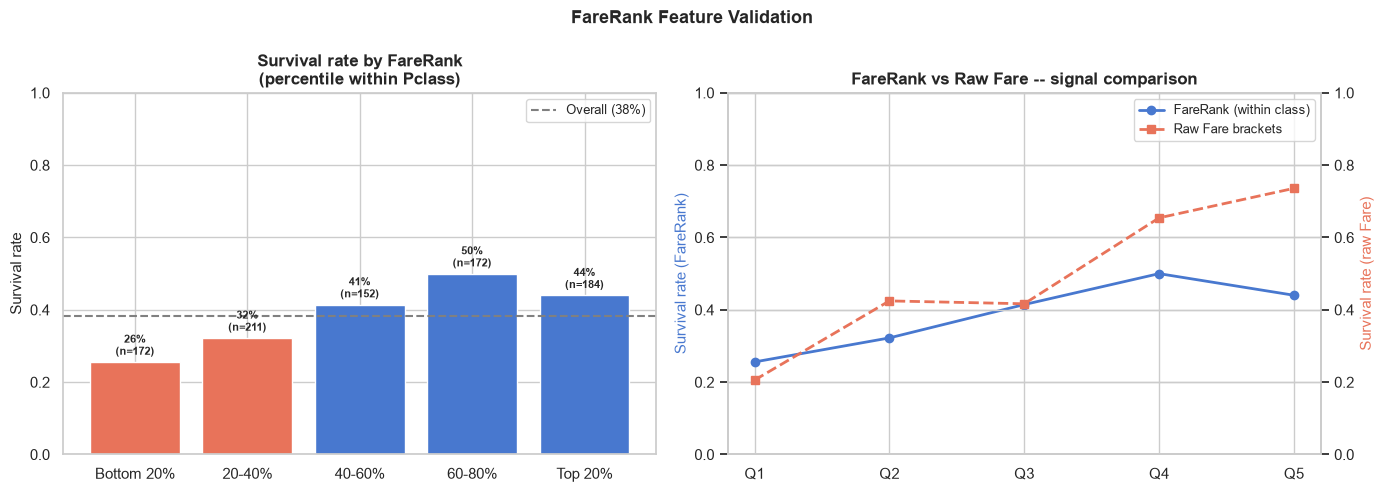

FareRank quintile survival rates (percentile within Pclass):
  Bottom 20%  : 25.6%  (n=172)
  20-40%      : 32.2%  (n=211)
  40-60%      : 41.4%  (n=152)
  60-80%      : 50.0%  (n=172)
  Top 20%     : 44.0%  (n=184)

Spread (top quintile - bottom quintile): 24.4%
Verdict: KEEP the FareRank feature -- it adds signal beyond Pclass
(KEEP/DROP = whether to feed this engineered feature into the models; no data rows are removed.)


In [21]:
tmp["FareRank"] = tmp.groupby("Pclass")["Fare"].rank(pct=True)
mean_surv = df["Survived"].mean()

tmp["FareRankBin"] = pd.cut(tmp["FareRank"], bins=5,
                             labels=["Bottom 20%", "20-40%", "40-60%", "60-80%", "Top 20%"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fr_surv = tmp.groupby("FareRankBin", observed=True)["Survived"].mean()
fr_cnt  = tmp.groupby("FareRankBin", observed=True)["Survived"].count()
colors = [BLUE if v > mean_surv else ORANGE for v in fr_surv.values]
bars = axes[0].bar(fr_surv.index, fr_surv.values, color=colors, edgecolor="white")
axes[0].axhline(mean_surv, ls="--", color="grey", lw=1.5, label=f"Overall ({mean_surv:.0%})")
axes[0].set_title("Survival rate by FareRank\n(percentile within Pclass)", fontweight="bold")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=9)
for b, (v, n) in zip(bars, zip(fr_surv.values, fr_cnt.values)):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.0%}\n(n={n})",
                 ha="center", fontsize=8, fontweight="bold")

fare_bins   = [0, 10, 20, 50, 100, 600]
fare_labels = ["0-10", "10-20", "20-50", "50-100", "100+"]
tmp["FareBin"] = pd.cut(tmp["Fare"], bins=fare_bins, labels=fare_labels)
raw_surv = tmp.groupby("FareBin", observed=True)["Survived"].mean()

axes[1].plot(range(len(fr_surv)), fr_surv.values, "o-", color=BLUE, lw=2,
             label="FareRank (within class)")
ax2 = axes[1].twinx()
ax2.plot(range(len(raw_surv)), raw_surv.values, "s--", color=ORANGE, lw=2,
         label="Raw Fare brackets")
axes[1].set_xticks(range(len(fr_surv)))
axes[1].set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
axes[1].set_ylabel("Survival rate (FareRank)", color=BLUE)
ax2.set_ylabel("Survival rate (raw Fare)", color=ORANGE)
axes[1].set_title("FareRank vs Raw Fare -- signal comparison", fontweight="bold")
axes[1].set_ylim(0, 1.0)
ax2.set_ylim(0, 1.0)
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle("FareRank Feature Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("FareRank quintile survival rates (percentile within Pclass):")
for lbl, v, n in zip(fr_surv.index, fr_surv.values, fr_cnt.values):
    print(f"  {str(lbl):12s}: {v:.1%}  (n={n})")

spread = fr_surv.max() - fr_surv.min()
print(f"\nSpread (top quintile - bottom quintile): {spread:.1%}")
verdict = "KEEP the FareRank feature -- it adds signal beyond Pclass" if spread > 0.10 \
          else "DROP the FareRank feature -- redundant with Pclass"
print(f"Verdict: {verdict}")
print("(KEEP/DROP = whether to feed this engineered feature into the models; no data rows are removed.)")

**Interpretation:**

- Survival rises from ~26% for the cheapest-in-class quintile to ~50% by the 4th quintile (top quintile ~44%) — a **24% spread**, well above the ~10% bar.
- Within a class, where you sat in the fare distribution genuinely mattered; FareRank captures intra-class wealth that raw Pclass misses.
- (*keep / drop* = whether the feature enters the model, not dropping data rows; the quintiles are only display bins — the feature itself is the continuous 0–1 percentile.)
- **Decision:** KEEP `FareRank`.

---
<a id='8-eda-summary--modelling-plan'></a>
## 8. EDA Summary & Modelling Plan

### Key predictive signals

| Rank | Feature | Signal | Survival rates |
|---|---|---|---|
| 1 | **Sex / Title** | Dominant | Female 74% vs male 19% |
| 2 | **Pclass / Fare** | Strong (correlated) | 1st 63%, 3rd 24%; within-class survivors paid a bit more |
| 3 | **Age** | Moderate | Children (0-12) ~58%; seniors (60+) lowest |
| 4 | **Family structure** (SibSp, Parch, FamilySize) | Moderate, non-linear | Solo 30%; small family 50%+; large family collapses |
| 5 | **Embarked** | Weak (Pclass confound) | C higher due to more 1st-class at Cherbourg |

### Raw features (from `train.csv`)

| Column | Dtype | Range / Classes | Missing | Decision |
|---|---|---|---|---|
| `Survived` | int (0/1) | 2 classes | 0% | **Target** |
| `PassengerId` | int | 1–891 (unique id) | 0% | Drop (no signal) |
| `Pclass` | int | 3 classes {1,2,3} | 0% | Use (categorical) |
| `Name` | str | 891 unique | 0% | Drop raw -> extract `Title` |
| `Sex` | str | 2 classes {female, male} | 0% | Use (one-hot) |
| `Age` | float | 0.42 – 80.0 | 19.9% | Use (impute by Title-median) |
| `SibSp` | int | 0 – 8 | 0% | Use (numeric) |
| `Parch` | int | 0 – 6 | 0% | Use (numeric) |
| `Ticket` | str | 681 unique | 0% | Drop raw -> derive `TicketGroupSize` |
| `Fare` | float | 0.0 – 512.33 | 0% | Use as `log1p(Fare)` + derive `FareRank` |
| `Cabin` | str | 147 unique | 77.1% | Drop (too sparse) |
| `Embarked` | str | 3 classes {C,Q,S} | 0.2% | Use (one-hot); fill 2 gaps with mode `S` |

### Engineered features

| Feature | Derived from | Dtype | Range / Classes | How |
|---|---|---|---|---|
| `Title` | `Name` | categorical | 7 classes: Mr, Miss, Mrs, Master, Dr, Rev, Other | regex honorific, rare titles -> `Other` |
| `FamilySize` | `SibSp` + `Parch` | int | 1 – 11 | SibSp + Parch + 1 |
| `IsAlone` | `FamilySize` | binary (0/1) | 2 classes | 1 if FamilySize == 1 |
| `TicketGroupSize` | `Ticket` | int | 1 – 7 | count of passengers sharing the ticket |
| `FareRank` | `Fare`, `Pclass` | float | 0.005 – 0.995 | fare percentile **within** Pclass |
| `log1p(Fare)` | `Fare` | float | 0.0 – 6.24 | log(1 + Fare) to tame right-skew |

### Combined feature list — model inputs

Everything fed to the models, grouped by how it is encoded. (`Age` shown post-imputation.)

| Feature | Dtype | Range / Classes | Encoding |
|---|---|---|---|
| `Age` | float | 0.42 – 80.0 | StandardScaler |
| `log1p(Fare)` | float | 0.0 – 6.24 | StandardScaler |
| `FareRank` | float | 0.005 – 0.995 | StandardScaler (already 0–1) |
| `FamilySize` | int | 1 – 11 | StandardScaler |
| `SibSp` | int | 0 – 8 | StandardScaler |
| `Parch` | int | 0 – 6 | StandardScaler |
| `TicketGroupSize` | int | 1 – 7 | StandardScaler |
| `IsAlone` | binary | {0, 1} | pass-through |
| `Sex` | categorical | 2 classes | one-hot |
| `Pclass` | categorical | 3 classes | one-hot |
| `Embarked` | categorical | 3 classes | one-hot |
| `Title` | categorical | 7 classes | one-hot |

**Totals:** 7 scaled numerics + 1 binary pass-through + 4 categoricals.
One-hot expands the categoricals to 2 + 3 + 3 + 7 = **15 columns** -> **23 model-input columns**.

**How each encoding works:**

- **StandardScaler** — standardises each numeric column to *mean 0, standard deviation 1* (`(x - mean) / std`). It does **not** squash to 0–1; values land roughly in ±3 and stay unbounded. We fit the scaler on the **training split only** and reuse those means/stds on validation and inference, so no information leaks from held-out data. This matters for the MLP (zero-centred, unit-variance inputs train stably); XGBoost is scale-invariant, so it simply ignores the transform.
- **Pass-through** — `IsAlone` is already a clean 0/1 indicator, so it enters the model unchanged. No scaling or encoding needed.
- **One-hot** — each categorical becomes one 0/1 column per class (e.g. `Title` -> 7 columns), with exactly one column set to 1 per row. This avoids implying a false order between categories (Pclass 3 is not '3x' Pclass 1). We keep **all** levels (no drop-first) because both XGBoost and the MLP are unaffected by the resulting collinearity that only destabilises linear models. Categories are learned on the training split; any unseen category at inference maps to all-zeros.

### Modelling implications

- **Baseline to beat:** 0.62 accuracy (majority-class)
- **Metrics:** Accuracy, F1, Precision, Recall, ROC-AUC
- **Models:** **XGBoost** (classical baseline) and a **PyTorch MLP** (deep learning).
- **Interactions matter:** Sex × Pclass is huge -- both XGBoost and the MLP capture it natively, so we don't hand-craft an interaction term.
- **Imbalance is mild (38/62):** we judge with F1/ROC-AUC rather than accuracy; explicit class weighting (`scale_pos_weight` / weighted BCE) is optional at 1.6:1.